## Setup

In [1]:
import numpy as np

item_count = 16
param_path = 'D:/data/base_cmr_parameters.json'

## Numba Implementation

In [2]:
from compmempy.models.memorysearch import Base_CMR
from compmempy.simulation import orthonormal_activation_matrix, visualize_2d_array
from compmempy.parameters import Parameters

full_parameters = Parameters(param_path)
parameters = full_parameters.fixed
items = np.eye(item_count)

numba_model = Base_CMR(items, item_count, parameters)
context_input = numba_model.mfc.activations(items[0])

context_input

array([0.        , 0.99999938, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ])

Pre-retrieval
[2.66127531e-04 3.56859183e-04 5.96937364e-04 9.98528928e-04
 1.67029253e-03 2.79398729e-03 4.67365137e-03 7.81786560e-03
 1.30773602e-02 2.18751971e-02 3.65918074e-02 6.12090655e-02
 1.02387664e-01 1.71269300e-01 2.86491282e-01 4.79229228e-01
 8.01632258e-01 0.00000000e+00]

[0.003449   0.01001379 0.0080792  0.00754771 0.00759902 0.00801181
 0.00881597 0.01020066 0.01253065 0.01643292 0.02296212 0.03388444
 0.05215499 0.08271718 0.1338402  0.21935641 0.36240393]

Starting retrieval
[5.11448956e-02 2.91858586e-05 4.88207404e-05 8.16650531e-05
 1.36605485e-04 2.28507271e-04 3.82236284e-04 6.39386994e-04
 1.06953668e-03 1.78907098e-03 2.99267434e-03 5.00600578e-03
 8.37381253e-03 1.40073223e-02 2.34307941e-02 3.91939375e-02
 6.55617870e-02 9.95337922e-01]

[0.003449   0.64565359 0.09066517 0.01808993 0.00698113 0.00443089
 0.00353589 0.00327758 0.00348808 0.00421165 0.00564231 0.00816687
 0.01246833 0.01971053 0.03185298 0.05218108 0.086195  ]

Recall 1
[8.05777417e-02 8.64

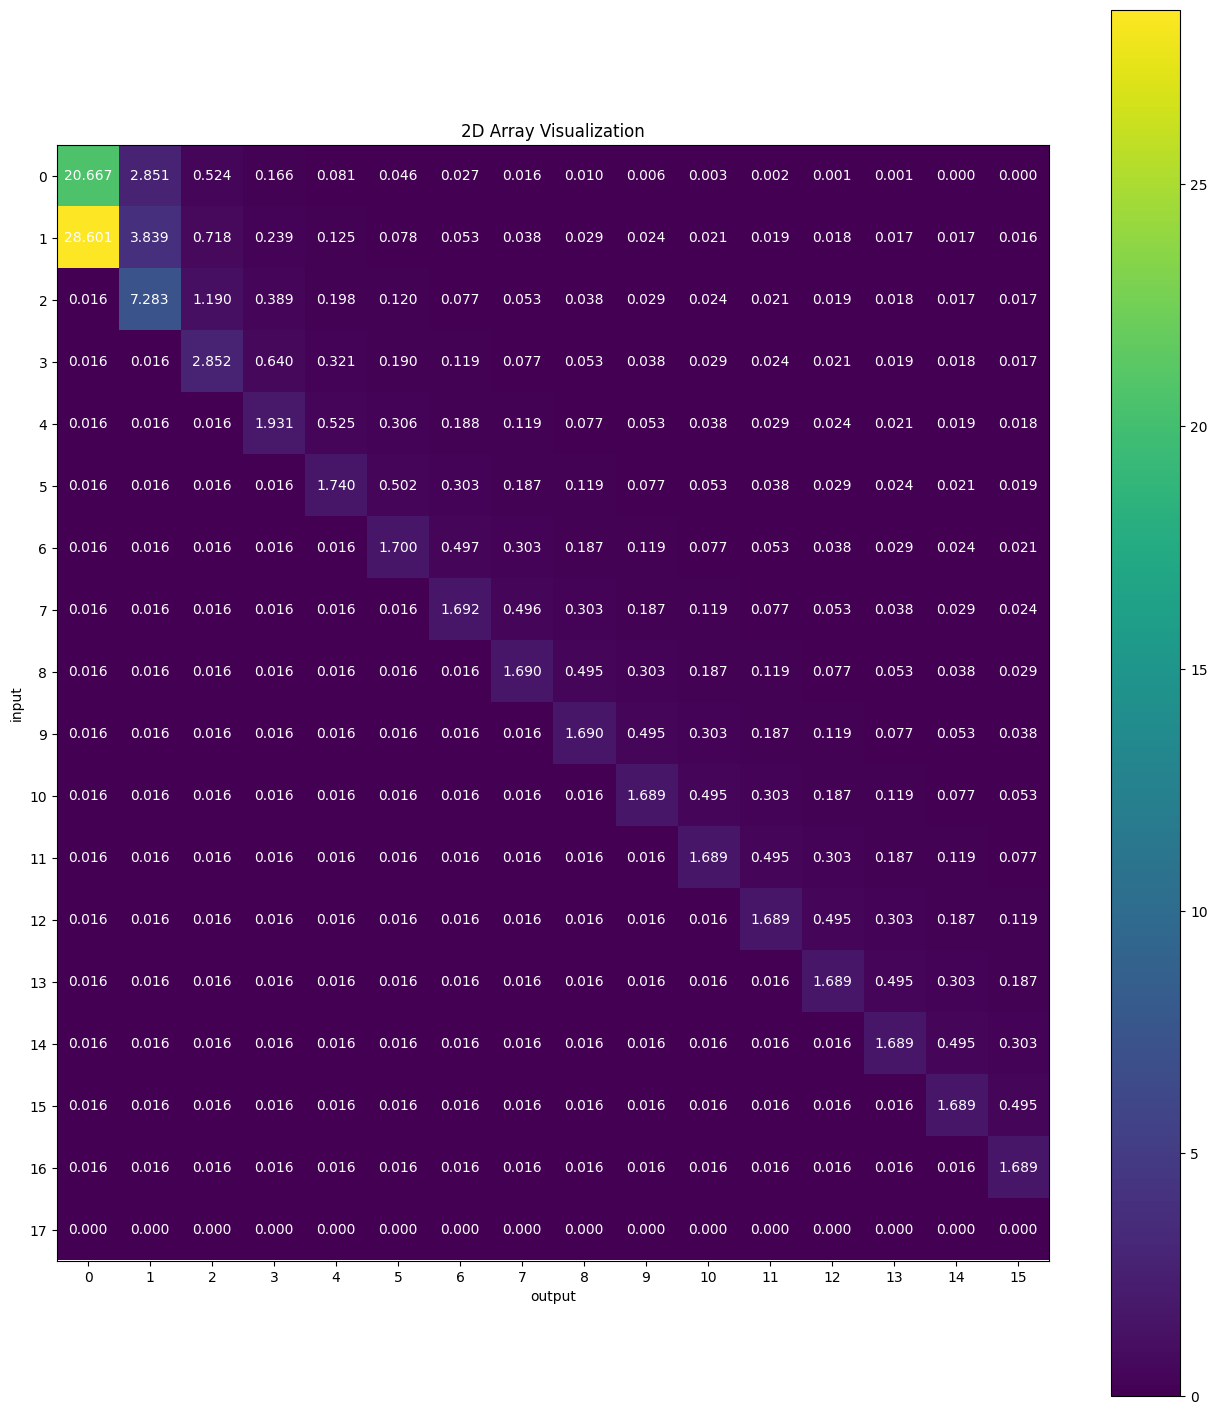

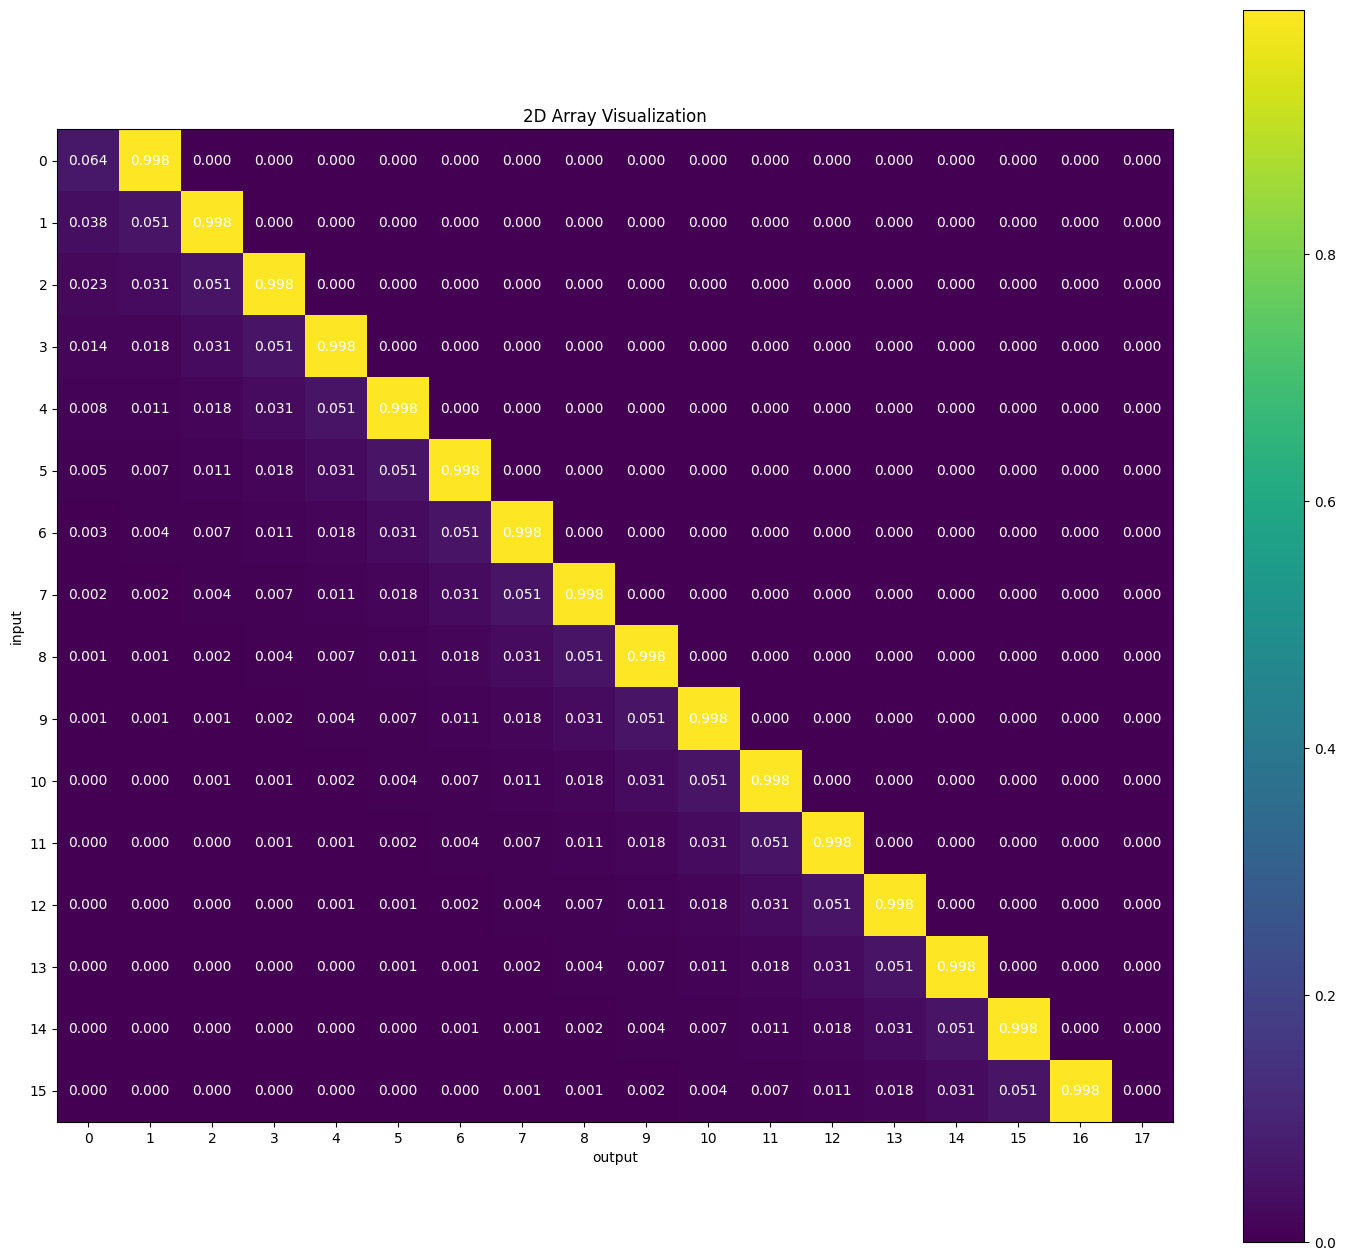

In [3]:
full_parameters = Parameters(param_path)
parameters = full_parameters.fixed
items = np.eye(item_count)

model = Base_CMR(items, item_count, parameters)
model.experience(items)

print('Pre-retrieval')
print(model.context.state())
print()

print(model.outcome_probabilities())
print()

print('Starting retrieval')
model.start_retrieving()
print(model.context.state())
print()

print(model.outcome_probabilities())
print()

print('Recall 1')
model.retrieve(1)
print(model.context.state())
print()

print(model.outcome_probabilities())
print()

print('Recall 2')
model.retrieve(2)
print(model.context.state())
print()

print(model.outcome_probabilities())
print()

print('Termination')
model.retrieve(0)
print(model.context.state())
print()

print(model.outcome_probabilities())
print()

visualize_2d_array(orthonormal_activation_matrix(model.mcf))
visualize_2d_array(orthonormal_activation_matrix(model.mfc))

In [5]:
experiment_count = 100000
numba_recalls = np.zeros((experiment_count, item_count), dtype=np.int32)

for i in range(experiment_count):
    items = np.eye(item_count)
    numba_model = Base_CMR(items, item_count, parameters)
    numba_model.experience(items)
    recalled = numba_model.free_recall()
    numba_recalls[i, :len(recalled)] = recalled+1

from jaxcmr.analyses import single_pres_spc, single_pres_pfr, single_pres_crp

single_pres_spc(numba_recalls, item_count), single_pres_pfr(numba_recalls, item_count), single_pres_crp(numba_recalls, item_count)

(array([0.96662, 0.93742, 0.8172 , 0.69298, 0.64713, 0.63419, 0.62476,
        0.6224 , 0.62062, 0.61396, 0.6074 , 0.60103, 0.59904, 0.59206,
        0.59018, 0.59123]),
 array([0.64438, 0.08958, 0.01912, 0.0076 , 0.00481, 0.00385, 0.00311,
        0.00359, 0.00427, 0.00569, 0.00783, 0.01269, 0.02043, 0.03104,
        0.05246, 0.08593]),
 array([0.34967846, 0.17822216, 0.11440772, 0.08782537, 0.07336131,
        0.07139407, 0.06791048, 0.06942064, 0.07082878, 0.07507804,
        0.08324311, 0.09395914, 0.10904995, 0.1331062 , 0.16840542,
        0.        , 0.35735241, 0.18594536, 0.11878882, 0.08133761,
        0.05915603, 0.04527856, 0.035946  , 0.02945354, 0.02473742,
        0.02191741, 0.02008051, 0.0191465 , 0.01873052, 0.01924095,
        0.01952678]))

## Jax Implementation

Pre-retrieval
[2.66127259e-04 3.56859091e-04 5.96937258e-04 9.98528791e-04
 1.67029246e-03 2.79398728e-03 4.67365142e-03 7.81786628e-03
 1.30773615e-02 2.18752008e-02 3.65918167e-02 6.12090863e-02
 1.02387704e-01 1.71269372e-01 2.86491424e-01 4.79229480e-01
 8.01632702e-01 0.00000000e+00]

[0.003449   0.0100138  0.00807922 0.00754773 0.00759904 0.00801183
 0.00881599 0.01020068 0.01253066 0.01643294 0.02296213 0.03388444
 0.05215499 0.08271716 0.13384017 0.21935633 0.3624038 ]

Starting retrieval
[5.1144898e-02 2.9185945e-05 4.8820886e-05 8.1665305e-05 1.3660592e-04
 2.2850800e-04 3.8223749e-04 6.3938909e-04 1.0695402e-03 1.7890770e-03
 2.9926847e-03 5.0060237e-03 8.3738426e-03 1.4007373e-02 2.3430880e-02
 3.9194085e-02 6.5562032e-02 9.9533790e-01]

[0.003449   0.6456523  0.09066506 0.01808997 0.0069812  0.00443096
 0.00353596 0.00327765 0.00348816 0.00421173 0.00564239 0.00816695
 0.01246842 0.01971063 0.03185312 0.05218126 0.08619525]

Recall 1
[8.05777609e-02 8.64924967e-01 2.435580

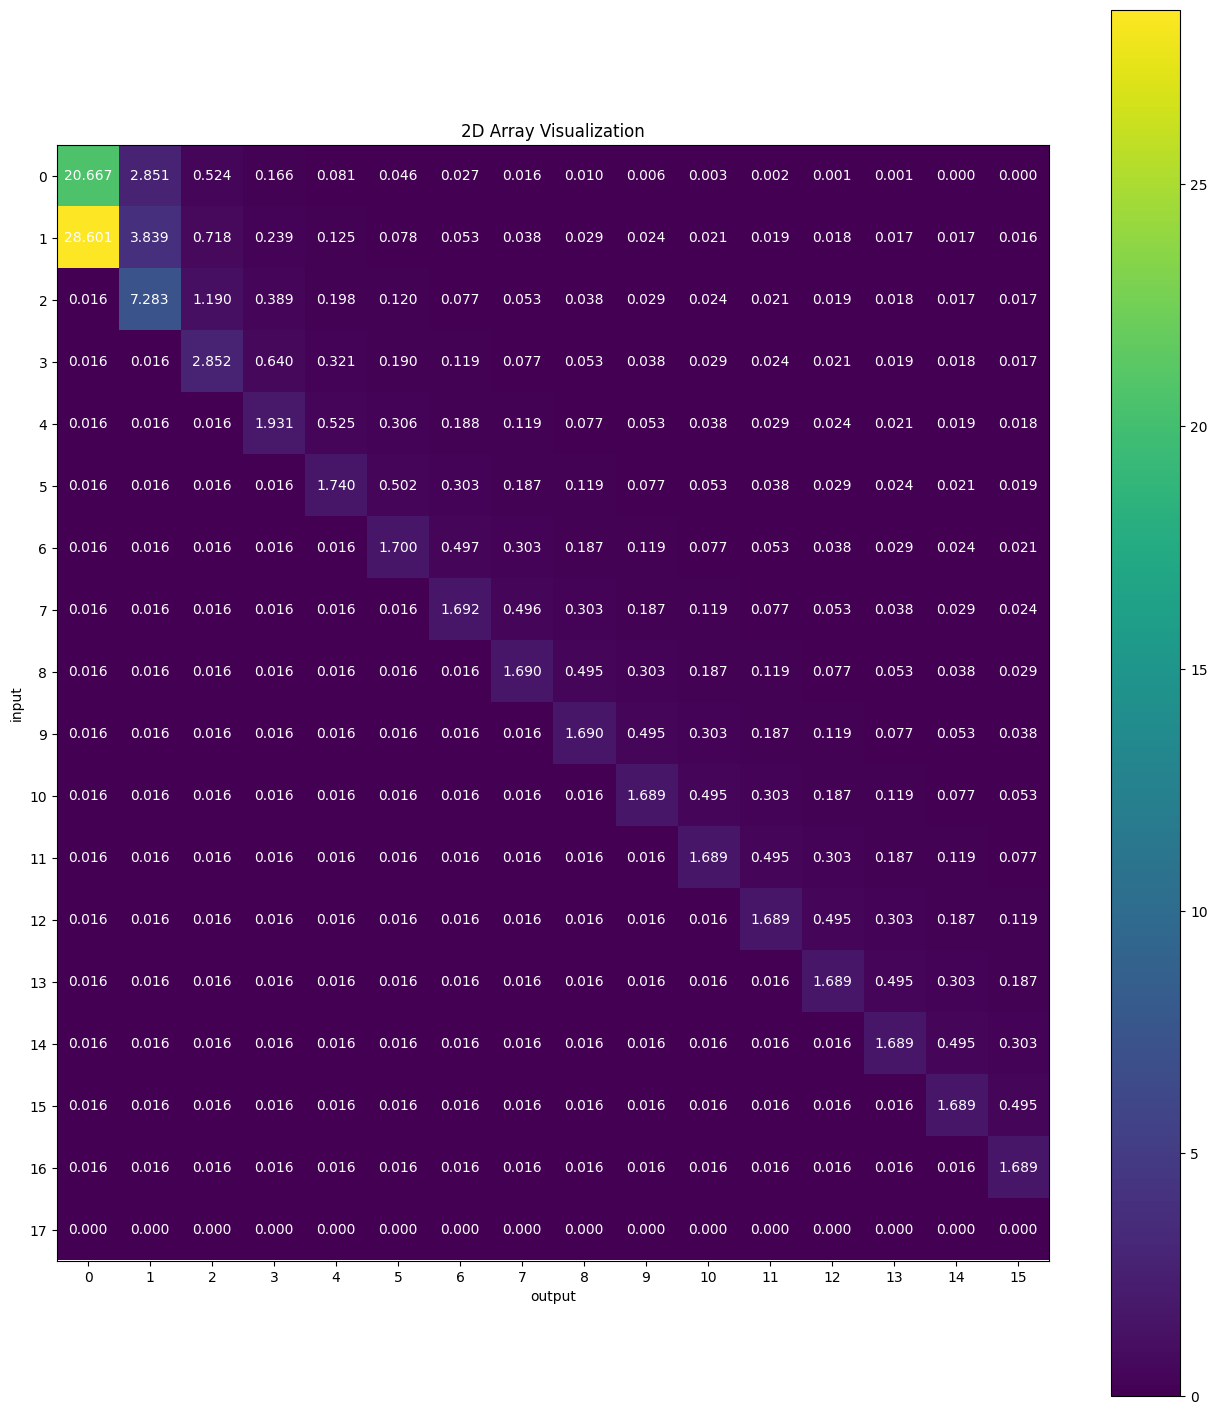

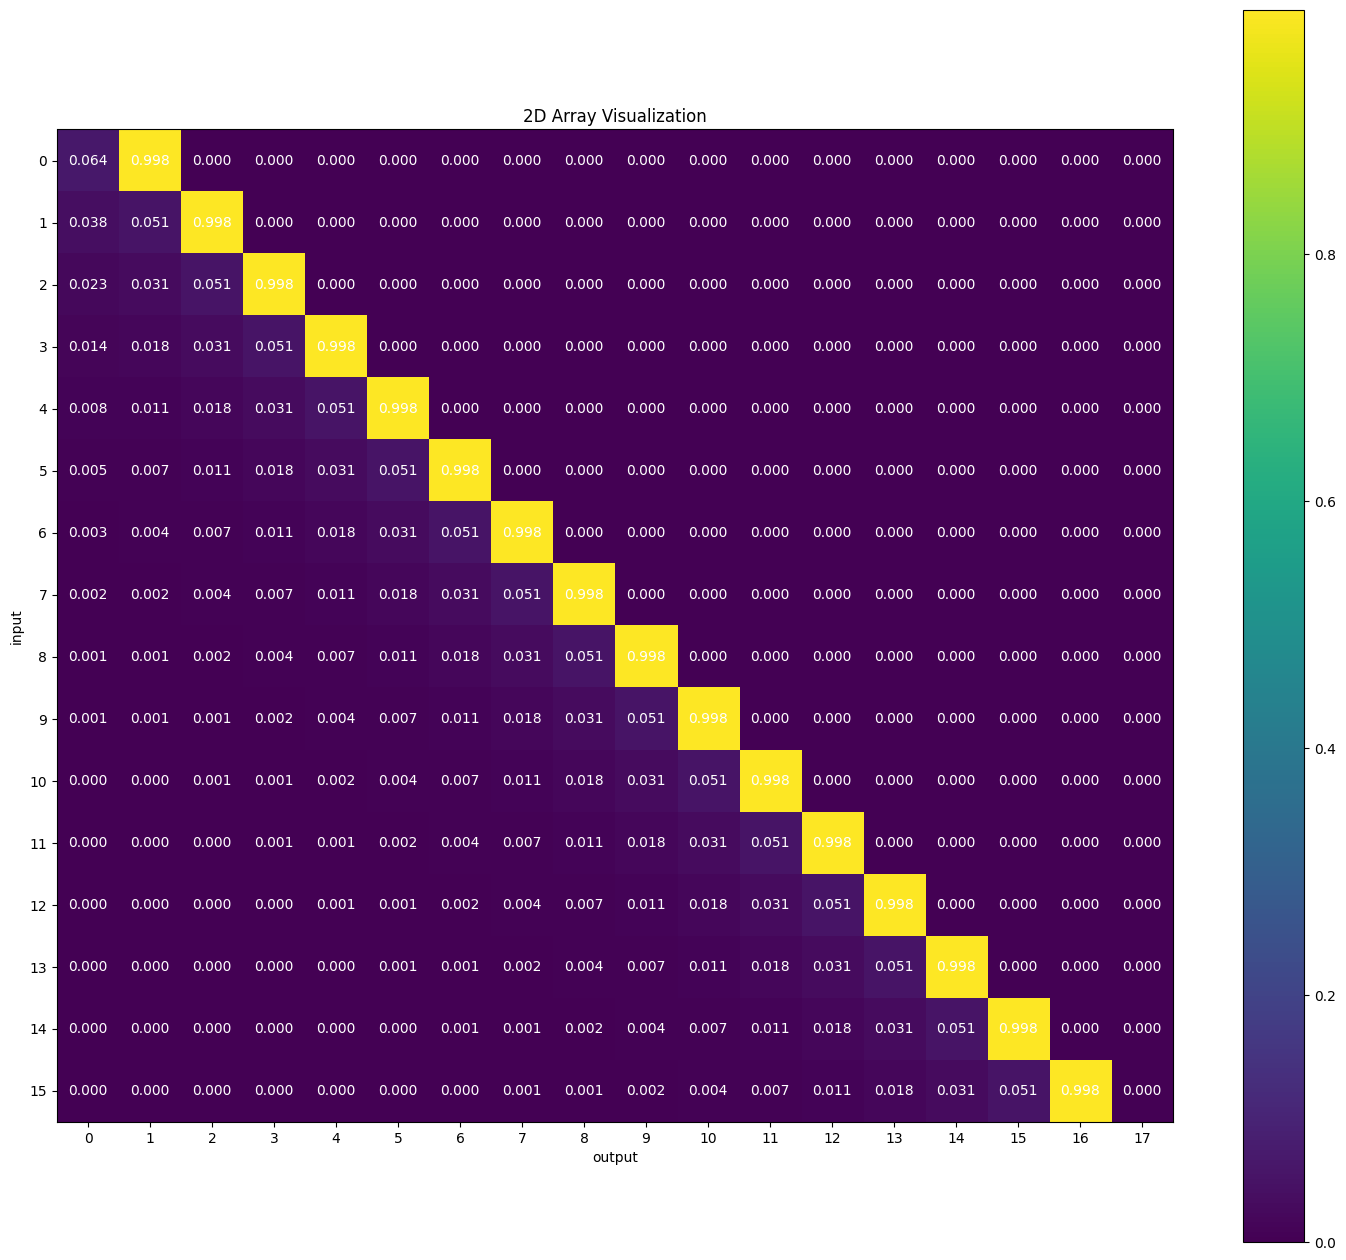

In [16]:
from jaxcmr.memorysearch import BaseCMR, experience, outcome_probabilities, start_retrieving, retrieve
from jax import lax
from jaxcmr.memory import probe
import json
import jax
jax.config.update('jax_enable_x64', False)

with open(param_path) as f:
    full_parameters = json.load(f)
parameters = full_parameters['fixed']

jax_model = BaseCMR.create(item_count, parameters)
jax_model = experience(jax_model)

print('Pre-retrieval')
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Starting retrieval')
jax_model = start_retrieving(jax_model)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Recall 1')
jax_model = retrieve(jax_model, 1)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Recall 2')
jax_model = retrieve(jax_model, 2)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Termination')
jax_model = retrieve(jax_model, 0)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

orthonormal_activation_matrix = lax.map(
    lambda _probe: probe(jax_model.mcf, _probe), 
    np.eye(jax_model.mcf.state.shape[0])
    )

# visualize_2d_array(jax_model.mfc.state)
visualize_2d_array(orthonormal_activation_matrix)

orthonormal_activation_matrix = lax.map(
    lambda _probe: probe(jax_model.mfc, _probe), 
    np.eye(jax_model.mfc.state.shape[0])
    )

# visualize_2d_array(jax_model.mfc.state)
visualize_2d_array(orthonormal_activation_matrix)



The discrepancy after termination is reasonable. The probability of termination (no recall) after termination should always be 1. And there's no reason to evolve the state of context after termination (since there will be no further simulation contingent on context state).

In [20]:
from jaxcmr.memorysearch import free_recall
import numpy as np

experiment_count = 100000
rng = jax.random.PRNGKey(0)

jax_model = BaseCMR.create(item_count, parameters)
jax_model = start_retrieving(experience(jax_model))
jax_recalls = jax.vmap(free_recall, in_axes=(None, 0))(
    jax_model, jax.random.split(rng, experiment_count))[1]
jax_recalls = np.array(jax_recalls)

(array([0.96695, 0.93825, 0.81837, 0.69457, 0.64785, 0.63412, 0.62707,
        0.62404, 0.61979, 0.61167, 0.6087 , 0.59924, 0.59615, 0.59172,
        0.5868 , 0.58685]),
 array([0.64704, 0.09176, 0.01818, 0.00684, 0.00456, 0.00383, 0.00319,
        0.00372, 0.00415, 0.00565, 0.00823, 0.01237, 0.02011, 0.03179,
        0.05037, 0.0849 ]),
 array([0.3527395 , 0.1743047 , 0.11423378, 0.0864627 , 0.07542452,
        0.06990998, 0.06855624, 0.0684402 , 0.07128611, 0.0754947 ,
        0.08432091, 0.09429545, 0.10946045, 0.13309252, 0.16822093,
        0.        , 0.35739031, 0.18689926, 0.11810397, 0.08146692,
        0.0590355 , 0.04519929, 0.03560262, 0.02892663, 0.02476627,
        0.02173484, 0.02051943, 0.01848246, 0.01821512, 0.0193249 ,
        0.01995667]))

In [22]:
single_pres_spc(jax_recalls, item_count), single_pres_spc(numba_recalls, item_count)

(array([0.96695, 0.93825, 0.81837, 0.69457, 0.64785, 0.63412, 0.62707,
        0.62404, 0.61979, 0.61167, 0.6087 , 0.59924, 0.59615, 0.59172,
        0.5868 , 0.58685]),
 array([0.96662, 0.93742, 0.8172 , 0.69298, 0.64713, 0.63419, 0.62476,
        0.6224 , 0.62062, 0.61396, 0.6074 , 0.60103, 0.59904, 0.59206,
        0.59018, 0.59123]))

In [23]:
single_pres_pfr(jax_recalls, item_count), single_pres_pfr(numba_recalls, item_count)

(array([0.64704, 0.09176, 0.01818, 0.00684, 0.00456, 0.00383, 0.00319,
        0.00372, 0.00415, 0.00565, 0.00823, 0.01237, 0.02011, 0.03179,
        0.05037, 0.0849 ]),
 array([0.64438, 0.08958, 0.01912, 0.0076 , 0.00481, 0.00385, 0.00311,
        0.00359, 0.00427, 0.00569, 0.00783, 0.01269, 0.02043, 0.03104,
        0.05246, 0.08593]))

In [24]:
single_pres_crp(jax_recalls, item_count), single_pres_crp(numba_recalls, item_count)

(array([0.3527395 , 0.1743047 , 0.11423378, 0.0864627 , 0.07542452,
        0.06990998, 0.06855624, 0.0684402 , 0.07128611, 0.0754947 ,
        0.08432091, 0.09429545, 0.10946045, 0.13309252, 0.16822093,
        0.        , 0.35739031, 0.18689926, 0.11810397, 0.08146692,
        0.0590355 , 0.04519929, 0.03560262, 0.02892663, 0.02476627,
        0.02173484, 0.02051943, 0.01848246, 0.01821512, 0.0193249 ,
        0.01995667]),
 array([0.34967846, 0.17822216, 0.11440772, 0.08782537, 0.07336131,
        0.07139407, 0.06791048, 0.06942064, 0.07082878, 0.07507804,
        0.08324311, 0.09395914, 0.10904995, 0.1331062 , 0.16840542,
        0.        , 0.35735241, 0.18594536, 0.11878882, 0.08133761,
        0.05915603, 0.04527856, 0.035946  , 0.02945354, 0.02473742,
        0.02191741, 0.02008051, 0.0191465 , 0.01873052, 0.01924095,
        0.01952678]))

## Instance CMR

Pre-retrieval
[2.66127259e-04 3.56859091e-04 5.96937258e-04 9.98528791e-04
 1.67029246e-03 2.79398728e-03 4.67365142e-03 7.81786628e-03
 1.30773615e-02 2.18752008e-02 3.65918167e-02 6.12090863e-02
 1.02387704e-01 1.71269372e-01 2.86491424e-01 4.79229480e-01
 8.01632702e-01 0.00000000e+00]

[0.003449   0.0100138  0.00807922 0.00754773 0.00759904 0.00801183
 0.00881599 0.01020068 0.01253067 0.01643294 0.02296213 0.03388445
 0.05215499 0.08271717 0.13384017 0.21935636 0.36240384]

Starting retrieval
[5.1144898e-02 2.9185945e-05 4.8820886e-05 8.1665305e-05 1.3660592e-04
 2.2850800e-04 3.8223749e-04 6.3938909e-04 1.0695402e-03 1.7890770e-03
 2.9926847e-03 5.0060237e-03 8.3738426e-03 1.4007373e-02 2.3430880e-02
 3.9194085e-02 6.5562032e-02 9.9533790e-01]

[0.003449   0.6456523  0.09066506 0.01808997 0.0069812  0.00443095
 0.00353596 0.00327765 0.00348816 0.00421173 0.00564239 0.00816695
 0.01246842 0.01971063 0.03185312 0.05218125 0.08619525]

Recall 1
[8.05777609e-02 8.64924967e-01 2.435580

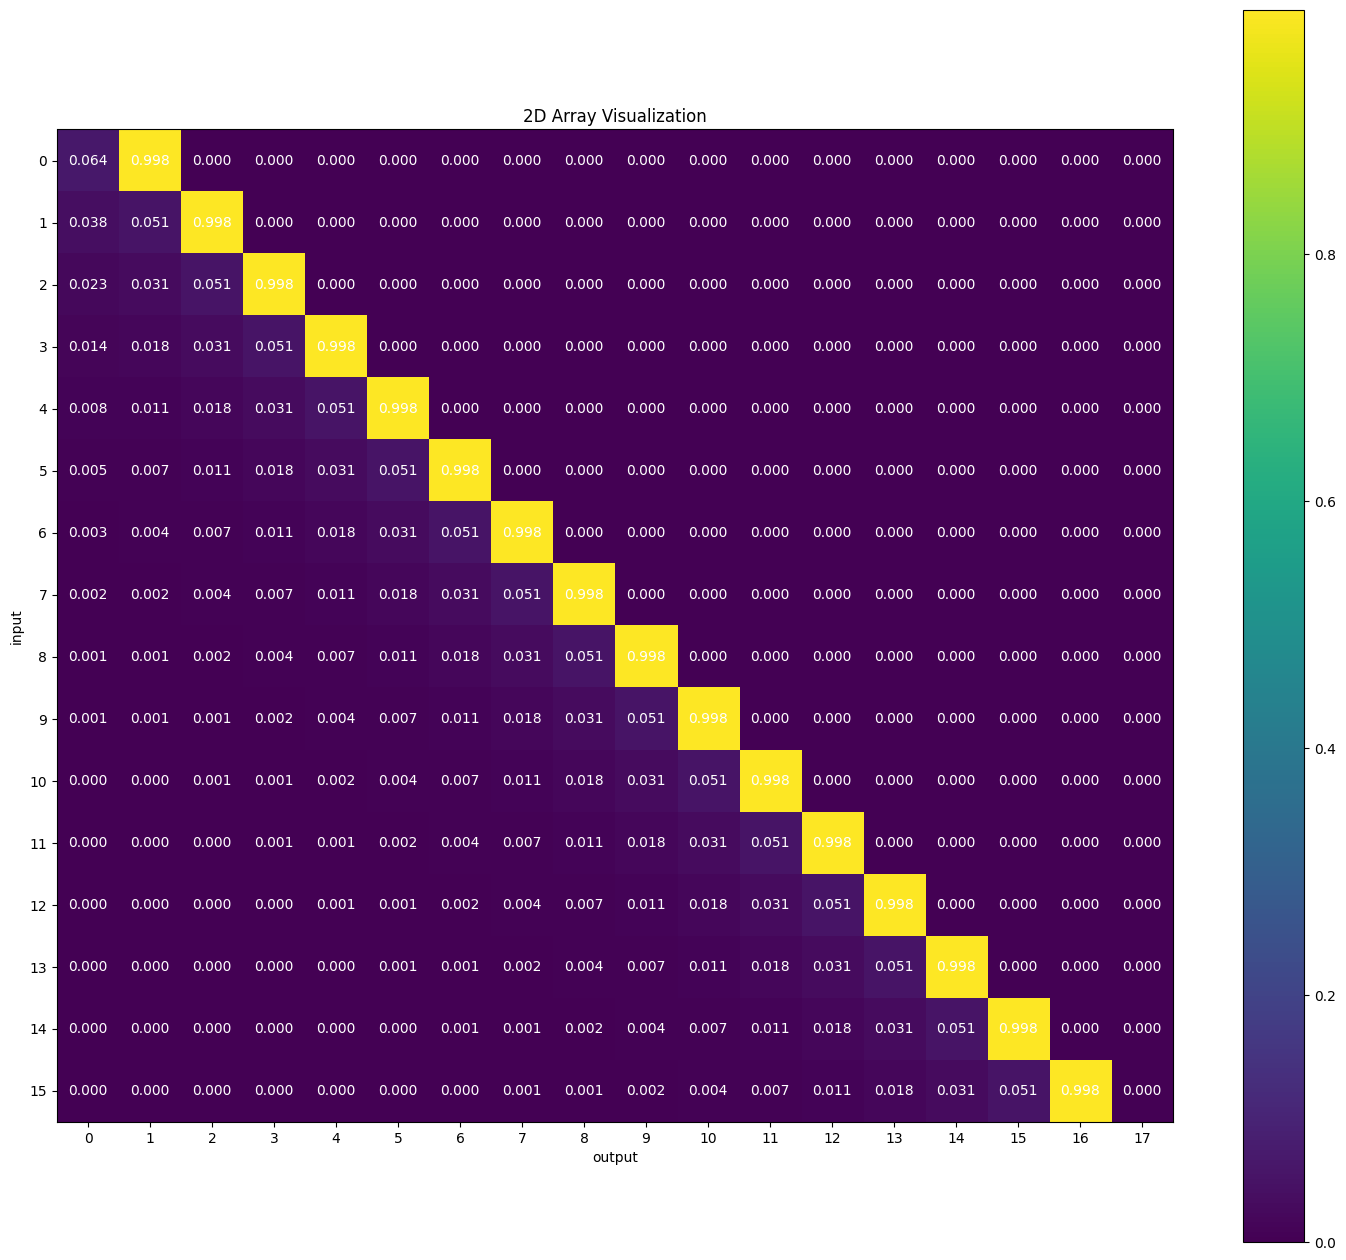

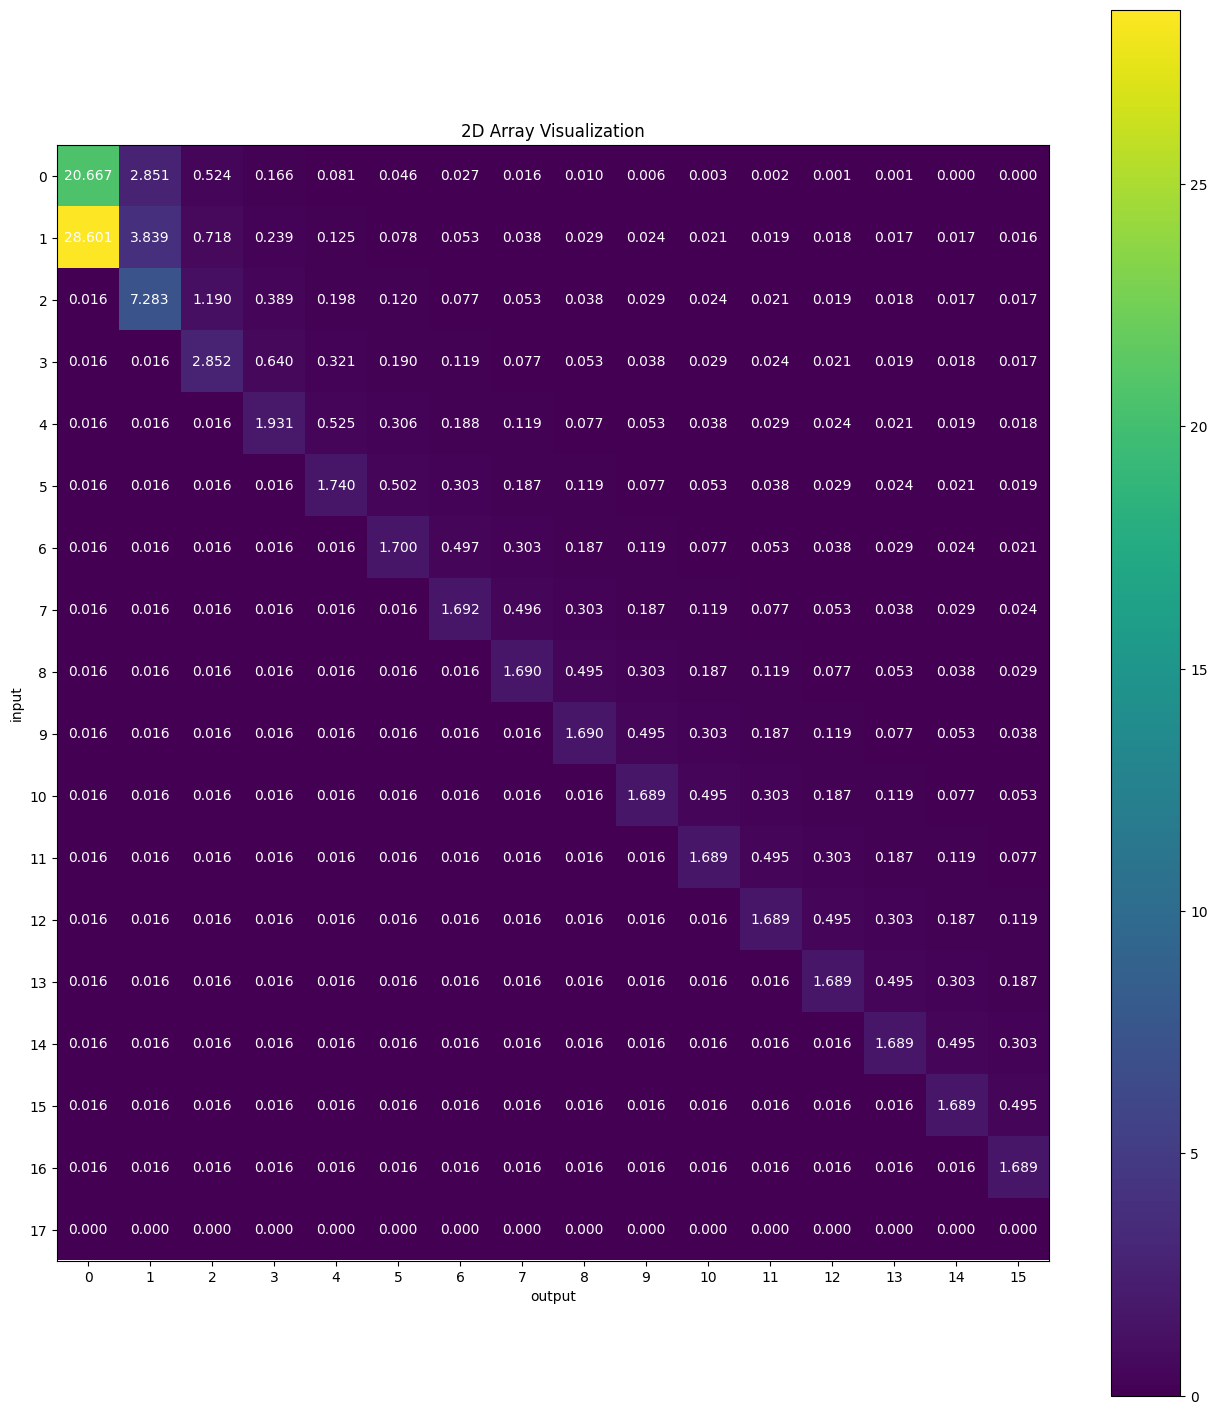

In [10]:
from jaxcmr.memorysearch import InstanceCMR, experience, outcome_probabilities, start_retrieving, retrieve

with open(param_path) as f:
    full_parameters = json.load(f)
parameters = full_parameters['fixed']

jax_model = InstanceCMR.create(item_count, parameters)
jax_model = experience(jax_model)

print('Pre-retrieval')
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Starting retrieval')
jax_model = start_retrieving(jax_model)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Recall 1')
jax_model = retrieve(jax_model, 1)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Recall 2')
jax_model = retrieve(jax_model, 2)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

print('Termination')
jax_model = retrieve(jax_model, 0)
print(jax_model.context.state)
print()

print(outcome_probabilities(jax_model))
print()

orthonormal_activation_matrix = lax.map(
    lambda _probe: probe(jax_model.mfc, _probe), 
    np.eye(jax_model.mfc.state.shape[0])
    )

# visualize_2d_array(jax_model.mfc.state)
visualize_2d_array(orthonormal_activation_matrix)

orthonormal_activation_matrix = lax.map(
    lambda _probe: probe(jax_model.mcf, _probe), 
    np.eye(item_count+2)
    )

# visualize_2d_array(jax_model.mfc.state)
visualize_2d_array(orthonormal_activation_matrix)